#### Contabilidad mensual

Esta notebook tiene como objetivo leer archivos .xls que se le envian todos los meses que corresponden a compras y ventas

In [1]:
### Libreris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date
print ("Liberias ok")

Liberias ok


In [ ]:
#archivo
archivo = Path("../data/raw/contabilidad/CONTABILIDAD 2026-01_ISLA.xlsx")
#Vemos cuales son los titulos de las hojas
excel = pd.ExcelFile(archivo)
excel.sheet_names


['COMPRAS', 'VENTAS']

In [36]:
#Se carga cada archivo por separado
df_compras = pd.read_excel(archivo, sheet_name="COMPRAS")
df_ventas = pd.read_excel(archivo, sheet_name="VENTAS")

In [8]:
#se prueba que sse cargue correctamente
df_compras.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,Razon Social:,ISLA ECOLOGICA S.A.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CUIT,30-71543101-3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MES,Enero,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fecha,Tipo Compr.,Punto de venta,Nº Compr.,Razon Social,Cuit,Condición,Concepto,Forma de Pago,Neto Gravado,"Iva % 10,5",Iva % 21,Iva 27%,IVA 3%,Perc. IIBB,Perc. Munic.,No Gravado y Exento,Total


In [9]:
#se prueba que sse cargue correctamente
df_ventas.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,Razon Social:,ISLA ECOLOGICA S.A.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CUIT,30-71543101-3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MES,Enero,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fecha,Tipo Compr.,Punto de venta,Nro. Compr.,Razón Social,Cuit/DNI,Neto Gravado 1*,"IVA % 10,5",IVA % 21,Iva 27%,IVA 3%,Perc. IIBB,Perc. Munic.,No Gravado y Exento,Total,Forma de Cobro


En ambos casos se ve que las primeras filas no hay que considerarlas y que la 4ta corresponde a los titulos

In [37]:
#Los volvemos a abrir sacando las primeras columnas
df_compras = pd.read_excel(archivo, sheet_name="COMPRAS", header=5)
df_ventas = pd.read_excel(archivo, sheet_name="VENTAS", header=5)

In [ ]:
df_compras.head()

In [ ]:
df_ventas.head()

In [ ]:
df_ventas.tail()

Esto era un solo archivo ahora lo aplicamos a toda la carpeta

In [42]:
# Esto e slo que vamos a usar en load!
carpeta = Path("../data/raw/contabilidad")
archivos = sorted(carpeta.glob("*.xlsx"))
compras = []
ventas = []

for archivo in archivos:
    print(archivo)
    # Compras
    df_c = pd.read_excel(archivo, sheet_name="COMPRAS", header=5)
    # Ventas
    df_v = pd.read_excel(archivo, sheet_name="VENTAS", header=5)

    # Trazabilidad
    df_c["archivo_origen"] = archivo.name
    df_v["archivo_origen"] = archivo.name

    compras.append(df_c)
    ventas.append(df_v)

df_compras = pd.concat(compras, ignore_index=True)
df_ventas = pd.concat(ventas, ignore_index=True)

#Eliminamos columnas sin nombrar que pudan estar en algunos archivos
df_compras = df_compras.loc[:, ~df_compras.columns.str.contains("^Unnamed")]
df_ventas = df_ventas.loc[:, ~df_ventas.columns.str.contains("^Unnamed")]

..\data\raw\contabilidad\CONTABILIDAD 2026-01_ISLA.xlsx
..\data\raw\contabilidad\CONTABILIDAD 2026-02_ISLA.xlsx
..\data\raw\contabilidad\CONTABILIDAD 2026-03_ISLA.xlsx
..\data\raw\contabilidad\CONTABILIDAD 2026-04_ISLA.xlsx
..\data\raw\contabilidad\CONTABILIDAD 2026-05_ISLA.xlsx
..\data\raw\contabilidad\CONTABILIDAD 2026-06_ISLA.xlsx


Se hace un pequeño EDA para explorar la informacion que tenemos en cada uno de los archivos
para reponder a preguntas como:
- columnas vacías,
- tipos de datos incorrectos,
- formatos de fecha distintos,
- columnas innecesarias,
- diferencias entre meses.

In [43]:
df_compras.info()

<class 'pandas.DataFrame'>
RangeIndex: 394 entries, 0 to 393
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Fecha                394 non-null    object 
 1   Tipo Compr.          394 non-null    str    
 2   Punto de venta       394 non-null    int64  
 3   Nº Compr.            394 non-null    float64
 4   Razon Social         394 non-null    str    
 5   Cuit                 394 non-null    object 
 6   Condición            394 non-null    str    
 7   Concepto             394 non-null    str    
 8   Forma de Pago        394 non-null    str    
 9   Neto Gravado         394 non-null    float64
 10  Iva % 10,5           8 non-null      float64
 11  Iva % 21             394 non-null    float64
 12  Iva 27%              2 non-null      float64
 13  IVA 3%               24 non-null     float64
 14  Perc. IIBB           10 non-null     float64
 15  Perc. Munic.         24 non-null     float64
 16  N

In [ ]:
def normalizar_columnas(df):
    return df.rename(columns={
        "Fecha": "fecha",
        "Tipo Compr.": "tipo_comprobante",
        "Punto de venta": "punto_venta",
        "Nº Compr.": "numero_comprobante",
        "Nro. Compr.": "numero_comprobante",
        "Razon Social": "razon_social",
        "Razón Social": "razon_social",
        "Cuit": "cuit",
        "Cuit/DNI": "cuit",
        "Condición": "condicion",
        "Concepto": "concepto",
        "Forma de Pago": "forma_pago",
        "Forma de Cobro": "forma_cobro",
        "Neto Gravado": "neto_gravado",
        "Neto Gravado 1*": "neto_gravado",
        "Iva % 10,5": "iva_10_5",
        "IVA % 21": "iva_21",
        "Iva 27%": "iva_27",
        "IVA 3%": "iva_3",
        "Perc. IIBB": "percepcion_iibb",
        "Perc. Munic.": "percepcion_municipal",
        "No Gravado y Exento": "no_gravado_exento",
        "Total": "total"
    })
df_compras = normalizar_columnas(df_compras)
df_ventas = normalizar_columnas(df_ventas)

print(df_compras.columns)
print(df_ventas.columns)

Index(['fecha', 'tipo_comprobante', 'punto_venta', 'numero_comprobante',
       'razon_social', 'cuit', 'condicion', 'concepto', 'forma_pago',
       'neto_gravado', 'iva_10_5', 'iva_21', 'iva_27', 'iva_3',
       'percepcion_iibb', 'percepcion_municipal', 'no_gravado_exento', 'total',
       'archivo_origen'],
      dtype='str')
Index(['fecha', 'tipo_comprobante', 'punto_venta', 'numero_comprobante',
       'razon_social', 'cuit', 'neto_gravado', 'iva_10_5', 'iva_21', 'iva_27',
       'iva_3', 'percepcion_iibb', 'percepcion_municipal', 'no_gravado_exento',
       'total', 'forma_cobro', 'archivo_origen'],
      dtype='str')


In [10]:
df_compras.columns

Index(['fecha', 'tipo_comprobante', 'punto_venta', 'numero_comprobante',
       'razon_social', 'cuit', 'condicion', 'concepto', 'forma_pago',
       'neto_gravado', 'iva_10_5', 'iva_21', 'iva_27', 'iva_3',
       'percepcion_iibb', 'percepcion_municipal', 'no_gravado_exento', 'total',
       'archivo_origen'],
      dtype='str')

In [11]:
df_compras.dtypes

fecha                   datetime64[ns]
tipo_comprobante                   str
punto_venta                      int64
numero_comprobante             float64
razon_social                       str
cuit                            object
condicion                          str
concepto                           str
forma_pago                         str
neto_gravado                   float64
iva_10_5                       float64
iva_21                         float64
iva_27                         float64
iva_3                          float64
percepcion_iibb                float64
percepcion_municipal           float64
no_gravado_exento              float64
total                          float64
archivo_origen                     str
dtype: object

In [45]:
#Vemos si hay nulos
df_compras.isna().sum()
# df_compras[df_compras["Fecha"].isna()]['archivo_origen']


fecha                     0
tipo_comprobante          0
punto_venta               0
numero_comprobante        0
razon_social              0
cuit                      0
condicion                 0
concepto                  0
forma_pago                0
neto_gravado              0
iva_10_5                386
iva_21                    0
iva_27                  392
iva_3                   370
percepcion_iibb         384
percepcion_municipal    370
no_gravado_exento       225
total                     0
archivo_origen            0
dtype: int64

In [46]:
# ventas
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha                 464 non-null    str    
 1   tipo_comprobante      464 non-null    str    
 2   punto_venta           464 non-null    int64  
 3   numero_comprobante    464 non-null    int64  
 4   razon_social          464 non-null    str    
 5   cuit                  38 non-null     float64
 6   neto_gravado          464 non-null    float64
 7   iva_10_5              0 non-null      float64
 8   iva_21                464 non-null    float64
 9   iva_27                0 non-null      float64
 10  iva_3                 0 non-null      float64
 11  percepcion_iibb       0 non-null      float64
 12  percepcion_municipal  0 non-null      float64
 13  no_gravado_exento     0 non-null      float64
 14  total                 464 non-null    float64
 15  forma_cobro           464 non-null

In [67]:
df_ventas.columns
df_ventas['prueba'] = df_ventas ["total"]

In [71]:
columnas_ventas = ['fecha', 'tipo_comprobante', 'punto_venta', 'numero_comprobante',
       'razon_social', 'cuit', 'neto_gravado', 'iva_10_5', 'iva_21', 'iva_27',
       'iva_3', 'percepcion_iibb', 'percepcion_municipal', 'no_gravado_exento',
       'total', 'forma_cobro', 'archivo_origen']
print(df_ventas.columns)

df_ventas = df_ventas[columnas_ventas]

print(df_ventas.columns)
print(df_compras.columns)

Index(['fecha', 'tipo_comprobante', 'punto_venta', 'numero_comprobante',
       'razon_social', 'cuit', 'neto_gravado', 'iva_10_5', 'iva_21', 'iva_27',
       'iva_3', 'percepcion_iibb', 'percepcion_municipal', 'no_gravado_exento',
       'total', 'forma_cobro', 'archivo_origen'],
      dtype='str')
Index(['fecha', 'tipo_comprobante', 'punto_venta', 'numero_comprobante',
       'razon_social', 'cuit', 'neto_gravado', 'iva_10_5', 'iva_21', 'iva_27',
       'iva_3', 'percepcion_iibb', 'percepcion_municipal', 'no_gravado_exento',
       'total', 'forma_cobro', 'archivo_origen'],
      dtype='str')
Index(['fecha', 'tipo_comprobante', 'punto_venta', 'numero_comprobante',
       'razon_social', 'cuit', 'condicion', 'concepto', 'forma_pago',
       'neto_gravado', 'iva_10_5', 'iva_21', 'iva_27', 'iva_3',
       'percepcion_iibb', 'percepcion_municipal', 'no_gravado_exento', 'total',
       'archivo_origen'],
      dtype='str')


In [15]:
df_ventas.dtypes

fecha                   datetime64[ns]
tipo_comprobante                   str
punto_venta                      int64
numero_comprobante               int64
razon_social                       str
cuit                           float64
neto_gravado                   float64
iva_10_5                       float64
iva_21                         float64
iva_27                         float64
iva_3                          float64
percepcion_iibb                float64
percepcion_municipal           float64
no_gravado_exento              float64
total                          float64
forma_cobro                        str
archivo_origen                     str
dtype: object

In [16]:
df_ventas.isna().sum()
# df_ventas.loc[
#     df_ventas["IVA % 21"].isna(),
#     ["archivo_origen", "Fecha", "IVA % 21"]
# ]

fecha                     0
tipo_comprobante          0
punto_venta               0
numero_comprobante        0
razon_social              0
cuit                    426
neto_gravado              0
iva_10_5                464
iva_21                    0
iva_27                  464
iva_3                   464
percepcion_iibb         464
percepcion_municipal    464
no_gravado_exento       464
total                     0
forma_cobro               0
archivo_origen            0
dtype: int64

In [47]:
#Formato fecha
# Compras
df_compras["fecha"] = (pd.to_datetime(df_compras["fecha"], dayfirst=True,errors="raise").astype("datetime64[ns]"))
# Ventas
df_ventas["fecha"] = (pd.to_datetime(df_ventas["fecha"], dayfirst=True, errors="raise").astype("datetime64[ns]"))

#S verifican que hayan qudao bien
print(df_compras.dtypes["fecha"])
print(df_ventas.dtypes["fecha"])

print(df_ventas['fecha'].head())
print(df_compras['fecha'].head())

datetime64[ns]
datetime64[ns]
0   2026-01-29
1   2026-01-06
2   2026-01-12
3   2026-01-15
4   2026-01-13
Name: fecha, dtype: datetime64[ns]
0   2026-01-20
1   2026-01-24
2   2026-01-02
3   2026-01-05
4   2026-01-06
Name: fecha, dtype: datetime64[ns]


In [15]:
# Cantidada de registros
print(len(df_compras))
print(len(df_ventas))

394
464


In [16]:
#Duplicados
df_compras.duplicated().sum()
df_ventas.duplicated().sum()

np.int64(0)

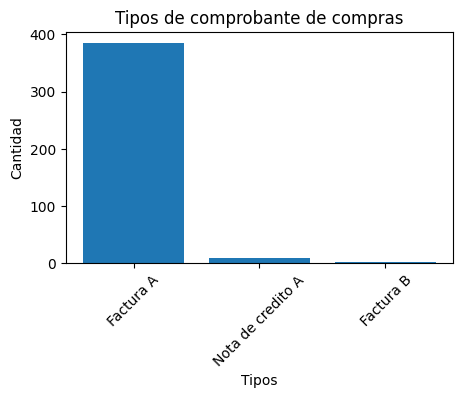

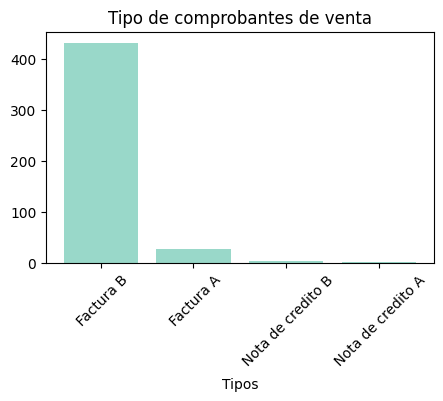

In [48]:
#Valores unicos
conteo_compras = df_compras["tipo_comprobante"].value_counts()

plt.figure(figsize=(5,3))
plt.bar(conteo_compras.index, conteo_compras.values)
plt.xticks(rotation = 45)
plt.xlabel("Tipos")
plt.title("Tipos de comprobante de compras")
plt.ylabel ("Cantidad")
plt.show()

conteo_ventas = df_ventas['tipo_comprobante'].value_counts()
plt.figure (figsize=(5,3))
plt.bar(conteo_ventas.index, conteo_ventas.values, color="#99d8c9")
plt.xticks(rotation = 45)
plt.title("Tipo de comprobantes de venta")
plt.xlabel("Tipos")
plt.show()

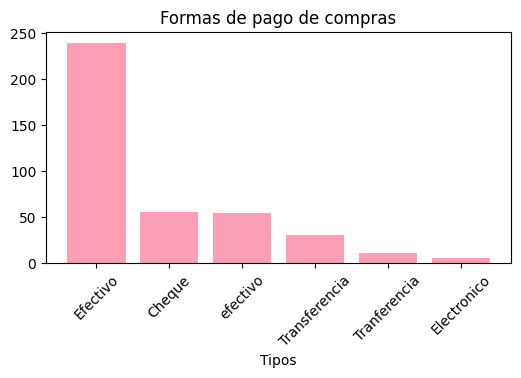

In [29]:
#Formas de pago
formas_pago_compras = df_compras["forma_pago"].value_counts()
plt.figure(figsize=(6,3))
plt.bar(formas_pago_compras.index, formas_pago_compras.values, color="#fa9fb5")
plt.title("Formas de pago de compras")
plt.xlabel("Tipos")
plt.xticks(rotation = 45)
plt.show()

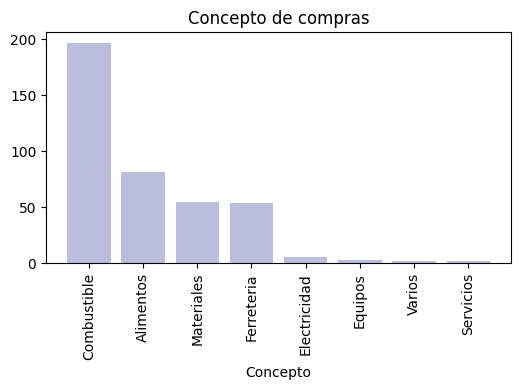

In [31]:
# Concepto de compras
concepto_compras = df_compras["concepto"].value_counts()
plt.figure(figsize=(6,3))
plt.bar(concepto_compras.index, concepto_compras.values, color="#bcbddc")
plt.title("Concepto de compras")
plt.xticks(rotation = 90)
plt.xlabel("Concepto")
plt.show()

In [20]:
df_ventas["forma_cobro"].value_counts()

forma_cobro
Efectivo         253
Transferencia    191
Cheque            20
Name: count, dtype: int64

In [ ]:
#Distribucion de importes
df_compras["total"].describe()

In [ ]:
df_ventas["total"].describe()

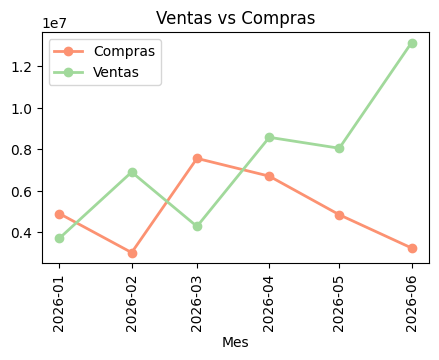

In [59]:
#Evolucion temproal
ventas_mes = (df_ventas.set_index("fecha").resample("MS")["total"].sum())
compras_mes = (df_compras.set_index("fecha").resample("MS")["total"].sum())
# Plot
plt.figure(figsize=(5,3))
plt.plot(compras_mes.index, compras_mes.values, color="#fc9272", linewidth=2,marker="o", label="Compras")
plt.plot(ventas_mes.index, ventas_mes.values, color="#a1d99b",linewidth=2, marker="o" , label="Ventas")
plt.title("Ventas vs Compras")
plt.xlabel("Mes")
plt.xticks(rotation = 90)
plt.legend()
plt.show()
#Quedo ok con el periodo correcto1

In [61]:
# Vemos el periodo de ambos porque a parece un documento con fecha 2025 que es incorrecta
print(min(df_ventas["fecha"]))
print(max(df_ventas["fecha"]))
print(min(df_compras["fecha"])) #Esta en compras 
print(max(df_compras["fecha"]))
#Buscamos cual es el archivo que esta mal y lo modificamos585
df_compras[df_compras["fecha"] == min(df_compras["fecha"])]

2026-01-02 00:00:00
2026-06-30 00:00:00
2026-01-02 00:00:00
2026-06-30 00:00:00


Salida de: df_compras[df_compras["fecha"] == min(df_compras["fecha"])]

<div align="center">
    <img src ="../img/img_consulta_8.png" width ="1000">
<div>

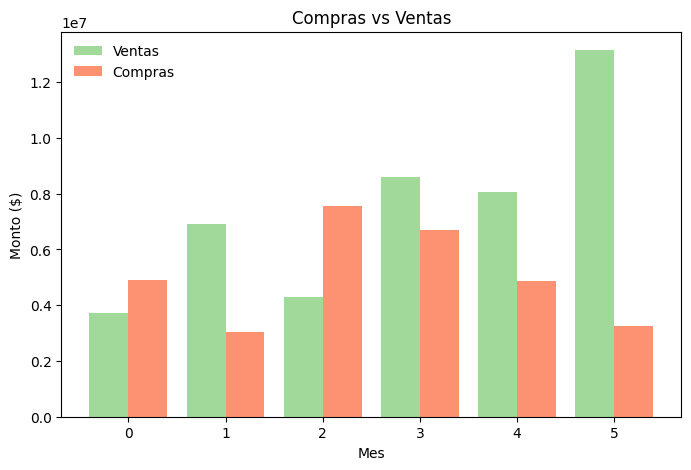

In [66]:
#Evolucion temproal
ventas_mes = (df_ventas.set_index("fecha").resample("MS")["total"].sum())
compras_mes = (df_compras.set_index("fecha").resample("MS")["total"].sum())

fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(ventas_mes))
ancho = 0.4
ax.bar(x-ancho/2, ventas_mes.values, width=ancho, label="Ventas", color="#a1d99b")
ax.bar(x+ancho/2, compras_mes.values, width= ancho, label ="Compras",color="#fc9272")
ax.set_title ("Compras vs Ventas")
ax.set_xlabel("Mes")
ax.set_ylabel("Monto ($)")
ax.legend(frameon=False)
plt.show()

In [ ]:
# Total segun razon social
df_compras.groupby("razon_social")["total"].sum().sort_values(ascending=False).head(10)

In [24]:
df_compras["tipo_comprobante"].value_counts()

tipo_comprobante
Factura A            385
Nota de credito A      8
 Factura B             1
Name: count, dtype: int64

In [26]:
df_compras["forma_pago"].value_counts()

forma_pago
Efectivo         239
Cheque            55
efectivo          54
Transferencia     30
Tranferencia      11
Electronico        5
Name: count, dtype: int64

In [ ]:
#Cuanto fue el iva de compras vs ventas
#Compras
print(df_compras["iva_21"].sum())
#Ventas
print(df_ventas["iva_21"].sum())

### Setear reglas que siempre deberian cumplirse


In [6]:
df_compras.columns

Index(['fecha', 'tipo_comprobante', 'punto_venta', 'numero_comprobante',
       'razon_social', 'cuit', 'condicion', 'concepto', 'forma_pago',
       'neto_gravado', 'iva_10_5', 'iva_21', 'iva_27', 'iva_3',
       'percepcion_iibb', 'percepcion_municipal', 'no_gravado_exento', 'total',
       'archivo_origen'],
      dtype='str')

In [7]:
# El valor total tiene que coincidir con la suma de todo
def validar_total(df):
    total_calculado = (
        df["neto_gravado"].fillna(0)
        + df["iva_21"].fillna(0)
        + df["iva_10_5"].fillna(0)
        + df["percepcion_municipal"].fillna(0)
        + df["percepcion_iibb"].fillna(0)
    )
    diferencia = (total_calculado - df["total"]).abs()
    assert (diferencia < 0.01).all(), "Hay comprobantes cuyo total no coincide."

In [ ]:
# Siempre son fechas pasadas
def validar_fecha(df):
    assert (df["Fecha"] <= pd.Timestamp.today()).all(),"Hay fechas futuras."

In [8]:
# No se pueden duplicar los datos
def validar_duplicados(df):
    duplicados = df.duplicated(subset=["tipo_comprobante","punto_venta","numero_comprobante"])
    assert not duplicados.any(), \
        "Hay comprobantes duplicados."

In [ ]:
# El nombre del archivo debe corresponderse con la feca
def validar_mes(df, anio, mes):
    assert ((df["Fecha"].dt.year == anio) & (df["Fecha"].dt.month == mes)).all(), "Hay registros fuera del mes del archivo."

#### Pruebas del pipeline